In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [3]:
import equinox as eqx
import esm  # pip install fair-esm==2.0.0
import esm2quinox
import jax.random as jrandom
import optax  # pip install optax
from dataset.dataset import initialize_datasets, Dataset_PEPBI
from functions.model import AFF_PREDICTOR,stripped_PREDICTOR
from functions.training import train_model, eval_step, train_model_validation
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax.random as jr
import jax
import pandas as pd
from torch.utils.data import DataLoader, RandomSampler, random_split
import jax.tree_util as jtu

pepbi dataset

In [4]:
# data_train = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/pepbi/min_max_scaled/train_data_pepbi.csv",
#     transform=esm2quinox.tokenise
# )
# train_loader = DataLoader(data_train,batch_size=20)
# sns.kdeplot(data_train.aff_Vals)

# data_test = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/pepbi/min_max_scaled/test_data_pepbi.csv",
#     transform=esm2quinox.tokenise
# )
# test_loader = DataLoader(data_test,batch_size=1)
# test_key_init = jrandom.PRNGKey(1)

mmpbsa dataset

In [5]:
# data = Dataset_PEPBI(
#     columns=["seq_prot", "seq_pept", "final_score"],
#     data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/mmpbsa/finished_data.csv",
#     transform=esm2quinox.tokenise
# )
# size_data = data.__len__()
# train_loader = DataLoader(data,batch_size=3)
# # split dataset into training and test set

# train_size = int(size_data * 0.9)
# test_size = size_data - train_size
# training_data, test_data = random_split(data, [train_size, test_size])
# #sampler = RandomSampler(training_data, replacement=True, num_samples=500)
# train_loader = DataLoader(training_data, batch_size=8)
# test_loader = DataLoader(test_data, batch_size=1)



weird dataset

In [ ]:
# data_train = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/weird_dataset/train.csv",
#     transform=esm2quinox.tokenise,
# )
# train_loader = DataLoader(data_train, batch_size=20)


# data_validation = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/weird_dataset/validation.csv",
#     transform=esm2quinox.tokenise,
# )
# validation_loader = DataLoader(data_validation, batch_size=1)

# data_test = Dataset_PEPBI(
#     columns=["Prot_Seq", "Pept_Seq", "Energy"],
#     data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/weird_dataset/test.csv",
#     transform=esm2quinox.tokenise,
# )
# test_loader = DataLoader(data_test, batch_size=1)

# test_key_init = jrandom.PRNGKey(1)

weird dataset - cosine similarity


In [4]:
data_train = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/weird_dataset/cosine_sim_scaled/train.csv",
    transform=esm2quinox.tokenise,
)
train_loader = DataLoader(data_train, batch_size=20)


data_validation = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/weird_dataset/cosine_sim_scaled/validation.csv",
    transform=esm2quinox.tokenise,
)
validation_loader = DataLoader(data_validation, batch_size=1)

data_test = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/weird_dataset/cosine_sim_scaled/test.csv",
    transform=esm2quinox.tokenise,
)
test_loader = DataLoader(data_test, batch_size=1)

test_key_init = jrandom.PRNGKey(1)

model initilialization

In [6]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t6_8M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(stripped_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))


In [10]:
# eqx.tree_serialise_leaves('/home/jkunz/master_uni_hd/internship_amsterdam/carbon/BindCraft_uva_internship/notebooks/test.txt',model_aff)

In [11]:
target_str =['QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSECLKRIGDELDSNMELQRMIAAVDTDSPREVFFRVAADMFSDGNFNWGRVVALFYFASKLVLKALCTKVPELIRTIMGWTLDFLRERLLGWIQDQGGWDGLLSYFG']
x_prot = esm2quinox.tokenise(target_str)

train model

In [ ]:
# train model
best_model, model_state, train_losses = train_model(
    training_DataLoader=train_loader,
    max_epochs=5,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

In [7]:
best_model, model_state, train_losses, val_losses = train_model_validation(
    training_DataLoader=train_loader,
    validation_Dataloader=validation_loader,
    max_epochs=5,
    model_aff=model_aff,
    model_state=model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

Epochs:   0%|          | 0/5 [00:00<?, ?it/s]












































































Epochs:  20%|██        | 1/5 [03:14<12:58, 194.66s/it]

[Epoch 1] Train Loss: 0.247381, Val Loss: 0.375749
	(New best model saved.)













































































Epochs:  40%|████      | 2/5 [06:34<09:53, 197.97s/it]

[Epoch 2] Train Loss: 0.223327, Val Loss: 0.356079
	(New best model saved.)


...

[Epoch 3] Train Loss: 0.213077, Val Loss: 0.413376













































































Epochs:  80%|████████  | 4/5 [13:29<03:23, 203.65s/it]

[Epoch 4] Train Loss: 0.207089, Val Loss: 0.458464













































































Epochs: 100%|██████████| 5/5 [17:02<00:00, 204.57s/it]

[Epoch 5] Train Loss: 0.214030, Val Loss: 0.350459
	(New best model saved.)
Training complete.


test

In [8]:
test_key_init = jrandom.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(test_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


[Entry 1] , Test Loss: 0.209, Predicted Y: 0.524, , True Y: 0.315
[Entry 2] , Test Loss: 0.024, Predicted Y: 0.665, , True Y: 0.641
[Entry 3] , Test Loss: 0.162, Predicted Y: 0.614, , True Y: 0.452
[Entry 4] , Test Loss: 0.465, Predicted Y: 0.685, , True Y: 0.220
[Entry 5] , Test Loss: 0.099, Predicted Y: 0.306, , True Y: 0.207
[Entry 6] , Test Loss: 0.156, Predicted Y: 0.410, , True Y: 0.254
[Entry 7] , Test Loss: 0.650, Predicted Y: 0.412, , True Y: -0.237
[Entry 8] , Test Loss: 0.327, Predicted Y: 0.407, , True Y: 0.080
[Entry 9] , Test Loss: 0.322, Predicted Y: 0.263, , True Y: 0.585
[Entry 10] , Test Loss: 0.349, Predicted Y: 0.367, , True Y: 0.018
[Entry 11] , Test Loss: 0.397, Predicted Y: 0.507, , True Y: 0.111
[Entry 12] , Test Loss: 0.011, Predicted Y: 0.449, , True Y: 0.438
[Entry 13] , Test Loss: 0.037, Predicted Y: 0.547, , True Y: 0.510
[Entry 14] , Test Loss: 0.566, Predicted Y: 0.388, , True Y: -0.178
[Entry 15] , Test Loss: 0.598, Predicted Y: 0.365, , True Y: -0.234
[

<Axes: >

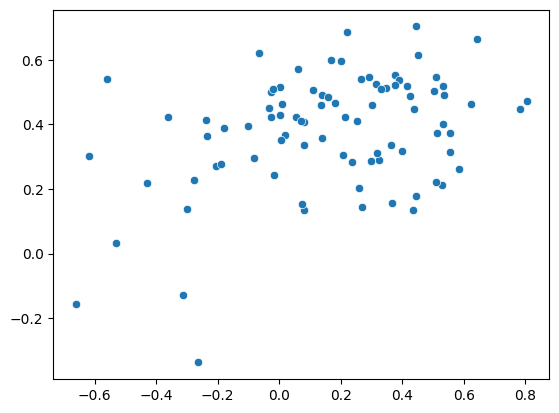

In [9]:
sns.scatterplot(x=y_val_list,y=pred_y_list)

<Axes: >

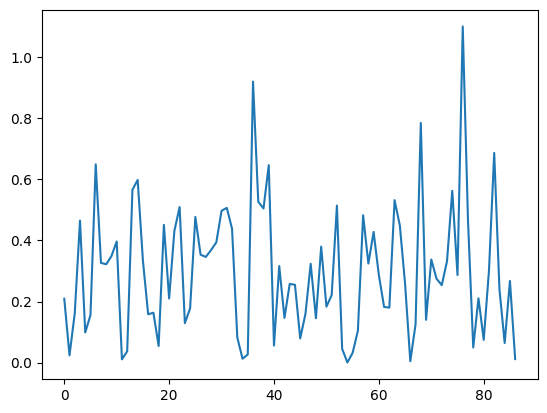

In [10]:
sns.lineplot(test_loss_list)

<Axes: ylabel='Density'>

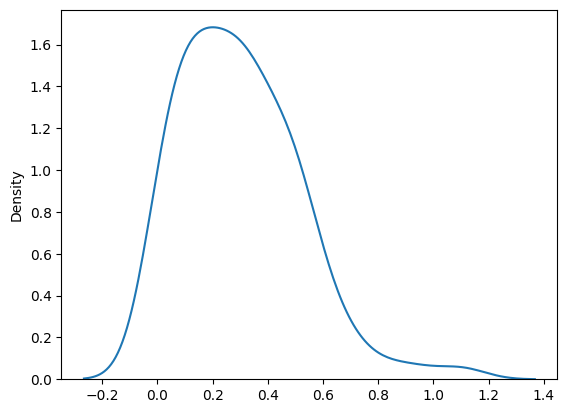

In [11]:
sns.kdeplot(test_loss_list)